In addition to demonstrating a deep learning approach to predicting STEM/quantum pathway readiness, this notebook is designed as a small proof-of-concept for aligning K–12 standards. The feature set and modeling task connect to CSTA K–12 Computer Science Standards in “Data and Analysis,” national K–12 data science learning progressions, and Q–12 quantum education efforts that call for coherent pathways from foundational CS/data skills into quantum literacy. The quantum pathway labels are interpreted as readiness tiers that can be associated with specific standards-aligned learning experiences (for example, data-rich investigations and introductory quantum simulations) in future curriculum design work.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")

print("Path to dataset files:", path)

100%|██████████| 12.1k/12.1k [00:00<00:00, 18.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/larsen0966/student-performance-data-set/versions/2


In [2]:
import os
import pandas as pd

# List contents of the downloaded directory
print(os.listdir(path))

['student-por.csv']


In [3]:
# Adjust filename to 'student-por.csv' based on the directory listing
csv_file_path = os.path.join(path, 'student-por.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
def map_pathway(g3):
    if g3 >= 15:
        return "High_STEM"
    elif g3 >= 10:
        return "Moderate_STEM"
    else:
        return "Support_STEM"

df["pathway_label"] = df["G3"].apply(map_pathway)

In [5]:
# Sanity checks for problem setup: inputs, target label, and shapes

import pandas as pd

# Confirm that the main DataFrame exists
try:
    print("DataFrame name: df")
    print("DataFrame shape (rows, columns):", df.shape)
except NameError:
    raise NameError("DataFrame 'df' is not defined yet. "
                    "Please run the cell that loads student-por.csv first.")

print("\nColumns preview:")
print(df.columns.tolist())

# Check the target label distribution
if "pathway_label" in df.columns:
    print("\nPathway label value counts (absolute):")
    print(df["pathway_label"].value_counts())

    print("\nPathway label proportions (relative):")
    print(df["pathway_label"].value_counts(normalize=True).round(3))
else:
    raise ValueError(
        "Column 'pathway_label' not found in df. "
        "Make sure you have already created pathway_label "
        "(the 3-class readiness tier) before running this cell."
    )

# If you already have train/val/test tensors, print their shapes
for name in ["X_train_tf", "X_val_tf", "X_test_tf"]:
    if name in globals():
        arr = globals()[name]
        print(f"\n{name} shape:", arr.shape)

DataFrame name: df
DataFrame shape (rows, columns): (649, 34)

Columns preview:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'pathway_label']

Pathway label value counts (absolute):
pathway_label
Moderate_STEM    418
High_STEM        131
Support_STEM     100
Name: count, dtype: int64

Pathway label proportions (relative):
pathway_label
Moderate_STEM    0.644
High_STEM        0.202
Support_STEM     0.154
Name: proportion, dtype: float64


In [6]:
import numpy as np

# Quick sanity check of final grade distribution
print(df["G3"].describe())
print(df["G3"].value_counts().sort_index())

# Define a 3-class "quantum pathway readiness" label
def map_quantum_pathway(g3):
    if g3 >= 15:
        return "High_Quantum_Pathway"      # strong STEM/CS/data foundation
    elif g3 >= 10:
        return "Moderate_Quantum_Pathway"  # can benefit from structured support
    else:
        return "Support_Quantum_Pathway"   # needs foundational strengthening

df["pathway_label"] = df["G3"].apply(map_quantum_pathway)

# Inspect class balance
df["pathway_label"].value_counts(normalize=True).rename("proportion")

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


,proportion
pathway_label,
Moderate_Quantum_Pathway,0.644068
High_Quantum_Pathway,0.201849
Support_Quantum_Pathway,0.154083


## Problem Statement and Scope

### Problem

We aim to predict K–12 students’ readiness for quantum and AI‑aligned STEM pathways using supervised deep learning models trained on student background and performance features. Concretely, we define a three‑class **quantum/STEM pathway readiness** label for each student:

- **High_Quantum_Pathway** – students showing strong readiness for advanced AI/quantum learning experiences.
- **Moderate_Quantum_Pathway** – students ready for core STEM and data‑rich computing experiences and introductory quantum literacy.
- **Support_Quantum_Pathway** – students who would benefit from additional academic and social‑emotional support before engaging deeply with advanced AI/quantum content.

Our prediction task is: given each student’s demographic, family, behavioral, and academic features from the Kaggle “Student Performance” dataset, predict which of these three readiness tiers they belong to.

### Inputs

The model input is a feature vector derived from the UCI/Kaggle **student‑por.csv** dataset. After preprocessing and encoding, each example includes:

- Categorical attributes such as school, sex, address type, family size, parental education levels, and parent occupations.
- Behavioral and contextual indicators such as study time, failures, absences, alcohol use, and free time.
- Academic performance measures such as first‑ and second‑period grades (G1, G2) that are commonly available to schools as early warning indicators.

All inputs are de‑identified and used for research only.

### Output

The model output is a 3‑class probability distribution over the readiness labels:

- \( p(\text{High\_Quantum\_Pathway} \mid x) \)
- \( p(\text{Moderate\_Quantum\_Pathway} \mid x) \)
- \( p(\text{Support\_Quantum\_Pathway} \mid x) \)

At inference time, we take the argmax of these probabilities to produce a single predicted readiness tier for each student.

### Educational Use Case and SBIR Alignment

In the broader SBIR concept, these readiness tiers are not used to track or label individual students in isolation. Instead, they act as inputs to an **equity‑aware matching layer** that helps districts and industry partners:

- Target professional development, mentoring, and sponsorships in AI and quantum pathways.
- Monitor which students are accessing high‑quality opportunities.
- Document equity and impact across schools and subgroups.

In future work, the same prediction models would be deployed **inside a quantum‑safe, privacy‑preserving federated infrastructure**, so that districts can compute readiness tiers locally without centralizing raw student data. In this course project, we focus only on building and evaluating the deep learning models; federated learning and post‑quantum cryptography are out of scope.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and target
# Drop G3 (final grade) and the derived label from features
X = df.drop(columns=["G3", "pathway_label"])
y = df["pathway_label"]

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# One-hot encode categoricals for the baseline model
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Encode labels as integers for the neural network
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
input_dim = X_train.shape[1]

print("Input dimension:", input_dim)
print("Classes:", list(label_encoder.classes_))

Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Input dimension: 41
Classes: ['High_Quantum_Pathway', 'Moderate_Quantum_Pathway', 'Support_Quantum_Pathway']


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Convert to tensors
X_train_tf = tf.convert_to_tensor(X_train.values, dtype=tf.float32)
X_val_tf = tf.convert_to_tensor(X_val.values, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test.values, dtype=tf.float32)

y_train_tf = tf.convert_to_tensor(y_train_enc, dtype=tf.int32)
y_val_tf = tf.convert_to_tensor(y_val_enc, dtype=tf.int32)
y_test_tf = tf.convert_to_tensor(y_test_enc, dtype=tf.int32)

# Build baseline MLP
baseline_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,827 (54.01 KB)

 Trainable params: 13,827 (54.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import tensorflow as tf

# Convert to tensors
X_train_tf = tf.convert_to_tensor(X_train.values, dtype=tf.float32)
X_val_tf = tf.convert_to_tensor(X_val.values, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test.values, dtype=tf.float32)

y_train_tf = tf.convert_to_tensor(y_train_enc, dtype=tf.int32)
y_val_tf = tf.convert_to_tensor(y_val_enc, dtype=tf.int32)
y_test_tf = tf.convert_to_tensor(y_test_enc, dtype=tf.int32)

## Architecture ablation

To strengthen technical depth, I compare multiple MLP variants that differ in depth, width, regularization, and normalization. This moves the project beyond a single neural network and shows how architectural choices affect macro-F1 and minority-class performance.

In [10]:
# =========================================================
# STEP 2: ARCHITECTURE ABLATION FOR TECHNICAL DEPTH
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

num_features = X_train_tf.shape[1]
num_classes = len(label_encoder.classes_)

def build_mlp(input_dim, hidden_units=[128, 64], dropout_rates=[0.3, 0.2],
              use_batchnorm=False, l2_reg=0.0):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for i, units in enumerate(hidden_units):
        model.add(
            layers.Dense(
                units,
                activation='relu',
                kernel_regularizer=keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
            )
        )
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        if i < len(dropout_rates) and dropout_rates[i] > 0:
            model.add(layers.Dropout(dropout_rates[i]))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

def train_and_eval_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test,
                         loss='sparse_categorical_crossentropy',
                         class_weight=None,
                         epochs=50,
                         batch_size=32,
                         verbose=0):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=['accuracy']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=verbose
    )

    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = y_test.numpy() if hasattr(y_test, "numpy") else np.array(y_test)

    report = classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    result = {
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average='macro'),
        "High F1": report[label_encoder.classes_[0]]["f1-score"],
        "Moderate F1": report[label_encoder.classes_[1]]["f1-score"],
        "Support F1": report[label_encoder.classes_[2]]["f1-score"],
        "Best Val Accuracy": max(history.history["val_accuracy"]),
        "Best Val Loss": min(history.history["val_loss"]),
        "Epochs Run": len(history.history["loss"]),
        "History": history,
        "Predictions": y_pred
    }
    return result, model

ablation_configs = [
    {
        "name": "MLP_2Layer_128_64",
        "hidden_units": [128, 64],
        "dropout_rates": [0.3, 0.2],
        "use_batchnorm": False,
        "l2_reg": 0.0
    },
    {
        "name": "MLP_2Layer_256_128_BN",
        "hidden_units": [256, 128],
        "dropout_rates": [0.4, 0.3],
        "use_batchnorm": True,
        "l2_reg": 0.0
    },
    {
        "name": "MLP_3Layer_256_128_64_BN",
        "hidden_units": [256, 128, 64],
        "dropout_rates": [0.4, 0.3, 0.2],
        "use_batchnorm": True,
        "l2_reg": 1e-4
    },
    {
        "name": "MLP_3Layer_128_128_64_L2",
        "hidden_units": [128, 128, 64],
        "dropout_rates": [0.3, 0.3, 0.2],
        "use_batchnorm": False,
        "l2_reg": 1e-4
    }
]

ablation_results = []
trained_ablation_models = {}

for cfg in ablation_configs:
    model = build_mlp(
        input_dim=num_features,
        hidden_units=cfg["hidden_units"],
        dropout_rates=cfg["dropout_rates"],
        use_batchnorm=cfg["use_batchnorm"],
        l2_reg=cfg["l2_reg"]
    )

    result, trained_model = train_and_eval_model(
        model=model,
        model_name=cfg["name"],
        X_train=X_train_tf,
        y_train=y_train_tf,
        X_val=X_val_tf,
        y_val=y_val_tf,
        X_test=X_test_tf,
        y_test=y_test_tf,
        verbose=0
    )
    ablation_results.append(result)
    trained_ablation_models[cfg["name"]] = trained_model

ablation_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["History", "Predictions"]}
    for r in ablation_results
]).sort_values(by="Macro F1", ascending=False)

display(ablation_df.style.format({
    "Test Accuracy": "{:.3f}",
    "Macro F1": "{:.3f}",
    "High F1": "{:.3f}",
    "Moderate F1": "{:.3f}",
    "Support F1": "{:.3f}",
    "Best Val Accuracy": "{:.3f}",
    "Best Val Loss": "{:.3f}"
}))

,Model,Test Accuracy,Macro F1,High F1,Moderate F1,Support F1,Best Val Accuracy,Best Val Loss,Epochs Run
2,MLP_3Layer_256_128_64_BN,0.867,0.835,0.850,0.898,0.759,0.918,0.377,30
3,MLP_3Layer_128_128_64_L2,0.857,0.823,0.821,0.891,0.759,0.907,0.295,28
0,MLP_2Layer_128_64,0.847,0.813,0.769,0.884,0.786,0.897,0.277,26
1,MLP_2Layer_256_128_BN,0.837,0.766,0.833,0.882,0.583,0.907,0.288,42


## Class-imbalance mitigation beyond class weights

Because the Support pathway is the smallest and hardest class, I add two additional experiments: focal loss and random oversampling. These are intended to test whether deep-learning-specific training choices improve minority-class detection more effectively than simple class weighting.

In [11]:
# =========================================================
# STEP 3: FOCAL LOSS MODEL
# =========================================================

import tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

y_train_np = y_train_tf.numpy() if hasattr(y_train_tf, "numpy") else np.array(y_train_tf)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weights_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights_dict)

def sparse_categorical_focal_loss(gamma=2.0, alpha=None):
    alpha = tf.constant(alpha, dtype=tf.float32) if alpha is not None else None

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.reshape(y_true, [-1])

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=1)

        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=1)
        focal_term = tf.pow(1.0 - p_t, gamma)

        if alpha is not None:
            alpha_factor = tf.gather(alpha, y_true)
            loss = alpha_factor * focal_term * ce
        else:
            loss = focal_term * ce

        return tf.reduce_mean(loss)

    return loss_fn

alpha_vector = [class_weights_dict[i] for i in range(num_classes)]

focal_model = build_mlp(
    input_dim=num_features,
    hidden_units=[256, 128, 64],
    dropout_rates=[0.4, 0.3, 0.2],
    use_batchnorm=True,
    l2_reg=1e-4
)

focal_result, focal_trained_model = train_and_eval_model(
    model=focal_model,
    model_name="MLP_FocalLoss_3Layer",
    X_train=X_train_tf,
    y_train=y_train_tf,
    X_val=X_val_tf,
    y_val=y_val_tf,
    X_test=X_test_tf,
    y_test=y_test_tf,
    loss=sparse_categorical_focal_loss(gamma=2.0, alpha=alpha_vector),
    verbose=0
)

focal_df = pd.DataFrame([{
    k: v for k, v in focal_result.items() if k not in ["History", "Predictions"]
}])

display(focal_df.style.format({
    "Test Accuracy": "{:.3f}",
    "Macro F1": "{:.3f}",
    "High F1": "{:.3f}",
    "Moderate F1": "{:.3f}",
    "Support F1": "{:.3f}",
    "Best Val Accuracy": "{:.3f}",
    "Best Val Loss": "{:.3f}"
}))

Class weights: {0: np.float64(1.644927536231884), 1: np.float64(0.5182648401826484), 2: np.float64(2.1619047619047618)}


,Model,Test Accuracy,Macro F1,High F1,Moderate F1,Support F1,Best Val Accuracy,Best Val Loss,Epochs Run
0,MLP_FocalLoss_3Layer,0.724,0.687,0.667,0.773,0.621,0.876,0.193,40


In [12]:
# =========================================================
# STEP 4: SIMPLE RANDOM OVERSAMPLING ON TRAINING SET ONLY
# =========================================================

import numpy as np
import pandas as pd

X_train_np = X_train_tf.numpy() if hasattr(X_train_tf, "numpy") else np.array(X_train_tf)
y_train_np = y_train_tf.numpy() if hasattr(y_train_tf, "numpy") else np.array(y_train_tf)

def random_oversample(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    classes, counts = np.unique(y, return_counts=True)
    max_count = counts.max()

    X_parts = []
    y_parts = []

    for cls in classes:
        X_cls = X[y == cls]
        y_cls = y[y == cls]

        if len(X_cls) < max_count:
            extra_idx = rng.choice(len(X_cls), size=max_count - len(X_cls), replace=True)
            X_resampled = np.vstack([X_cls, X_cls[extra_idx]])
            y_resampled = np.concatenate([y_cls, y_cls[extra_idx]])
        else:
            X_resampled = X_cls
            y_resampled = y_cls

        X_parts.append(X_resampled)
        y_parts.append(y_resampled)

    X_bal = np.vstack(X_parts)
    y_bal = np.concatenate(y_parts)

    shuffle_idx = rng.permutation(len(y_bal))
    return X_bal[shuffle_idx], y_bal[shuffle_idx]

X_train_over, y_train_over = random_oversample(X_train_np, y_train_np)

print("Original class counts:", pd.Series(y_train_np).value_counts().sort_index().to_dict())
print("Oversampled class counts:", pd.Series(y_train_over).value_counts().sort_index().to_dict())

X_train_over_tf = tf.convert_to_tensor(X_train_over, dtype=tf.float32)
y_train_over_tf = tf.convert_to_tensor(y_train_over, dtype=tf.int32)

oversample_model = build_mlp(
    input_dim=num_features,
    hidden_units=[256, 128, 64],
    dropout_rates=[0.4, 0.3, 0.2],
    use_batchnorm=True,
    l2_reg=1e-4
)

oversample_result, oversample_trained_model = train_and_eval_model(
    model=oversample_model,
    model_name="MLP_Oversampled_3Layer",
    X_train=X_train_over_tf,
    y_train=y_train_over_tf,
    X_val=X_val_tf,
    y_val=y_val_tf,
    X_test=X_test_tf,
    y_test=y_test_tf,
    verbose=0
)

oversample_df = pd.DataFrame([{
    k: v for k, v in oversample_result.items() if k not in ["History", "Predictions"]
}])

display(oversample_df.style.format({
    "Test Accuracy": "{:.3f}",
    "Macro F1": "{:.3f}",
    "High F1": "{:.3f}",
    "Moderate F1": "{:.3f}",
    "Support F1": "{:.3f}",
    "Best Val Accuracy": "{:.3f}",
    "Best Val Loss": "{:.3f}"
}))

Original class counts: {0: 92, 1: 292, 2: 70}
Oversampled class counts: {0: 292, 1: 292, 2: 292}


,Model,Test Accuracy,Macro F1,High F1,Moderate F1,Support F1,Best Val Accuracy,Best Val Loss,Epochs Run
0,MLP_Oversampled_3Layer,0.847,0.818,0.850,0.878,0.727,0.918,0.259,23


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train a simple Random Forest baseline on the same features
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train_tf, y_train_tf)

# Evaluate on validation and test sets
y_val_pred_rf = rf_model.predict(X_val_tf)
y_test_pred_rf = rf_model.predict(X_test_tf)

val_acc_rf = accuracy_score(y_val_tf, y_val_pred_rf)
test_acc_rf = accuracy_score(y_test_tf, y_test_pred_rf)

print(f"Random Forest validation accuracy: {val_acc_rf:.3f}")
print(f"Random Forest test accuracy:       {test_acc_rf:.3f}\n")

# Detailed test metrics
print("=== Random Forest – Test Set Classification Report ===")
print(classification_report(
    y_test_tf,
    y_test_pred_rf,
    target_names=label_encoder.classes_,
    digits=3,
))

print("Random Forest – Test Set Confusion Matrix:")
print(confusion_matrix(y_test_tf, y_test_pred_rf))

Random Forest validation accuracy: 0.918
Random Forest test accuracy:       0.878

=== Random Forest – Test Set Classification Report ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.941     0.800     0.865        20
Moderate_Quantum_Pathway      0.849     0.984     0.912        63
 Support_Quantum_Pathway      1.000     0.533     0.696        15

                accuracy                          0.878        98
               macro avg      0.930     0.772     0.824        98
            weighted avg      0.891     0.878     0.869        98

Random Forest – Test Set Confusion Matrix:
[[16  4  0]
 [ 1 62  0]
 [ 0  7  8]]


## Unified model comparison

This section compares all deep-learning variants and the Random Forest reference using the same test split. I focus on accuracy, macro-F1, and class-specific F1, especially Support-tier performance.

In [14]:
# =========================================================
# STEP 5: MASTER COMPARISON TABLE
# =========================================================

from sklearn.metrics import f1_score, classification_report, accuracy_score
import pandas as pd
import numpy as np

def evaluate_rf_for_table(rf_model, X_test, y_test, label_encoder):
    X_test_np = X_test.numpy() if hasattr(X_test, "numpy") else np.array(X_test)
    y_true = y_test.numpy() if hasattr(y_test, "numpy") else np.array(y_test)
    y_pred = rf_model.predict(X_test_np)

    report = classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    return {
        "Model": "Random Forest",
        "Test Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "High F1": report[label_encoder.classes_[0]]["f1-score"],
        "Moderate F1": report[label_encoder.classes_[1]]["f1-score"],
        "Support F1": report[label_encoder.classes_[2]]["f1-score"]
    }

comparison_rows = []

for r in ablation_results:
    comparison_rows.append({
        "Model": r["Model"],
        "Test Accuracy": r["Test Accuracy"],
        "Macro F1": r["Macro F1"],
        "High F1": r["High F1"],
        "Moderate F1": r["Moderate F1"],
        "Support F1": r["Support F1"]
    })

comparison_rows.append({
    "Model": focal_result["Model"],
    "Test Accuracy": focal_result["Test Accuracy"],
    "Macro F1": focal_result["Macro F1"],
    "High F1": focal_result["High F1"],
    "Moderate F1": focal_result["Moderate F1"],
    "Support F1": focal_result["Support F1"]
})

comparison_rows.append({
    "Model": oversample_result["Model"],
    "Test Accuracy": oversample_result["Test Accuracy"],
    "Macro F1": oversample_result["Macro F1"],
    "High F1": oversample_result["High F1"],
    "Moderate F1": oversample_result["Moderate F1"],
    "Support F1": oversample_result["Support F1"]
})

comparison_rows.append(evaluate_rf_for_table(rf_model, X_test_tf, y_test_tf, label_encoder))

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["Macro F1", "Support F1"],
    ascending=False
).reset_index(drop=True)

display(comparison_df.style.format({
    "Test Accuracy": "{:.3f}",
    "Macro F1": "{:.3f}",
    "High F1": "{:.3f}",
    "Moderate F1": "{:.3f}",
    "Support F1": "{:.3f}"
}))

,Model,Test Accuracy,Macro F1,High F1,Moderate F1,Support F1
0,MLP_3Layer_256_128_64_BN,0.867,0.835,0.850,0.898,0.759
1,Random Forest,0.878,0.824,0.865,0.912,0.696
2,MLP_3Layer_128_128_64_L2,0.857,0.823,0.821,0.891,0.759
3,MLP_Oversampled_3Layer,0.847,0.818,0.850,0.878,0.727
4,MLP_2Layer_128_64,0.847,0.813,0.769,0.884,0.786
5,MLP_2Layer_256_128_BN,0.837,0.766,0.833,0.882,0.583
6,MLP_FocalLoss_3Layer,0.724,0.687,0.667,0.773,0.621


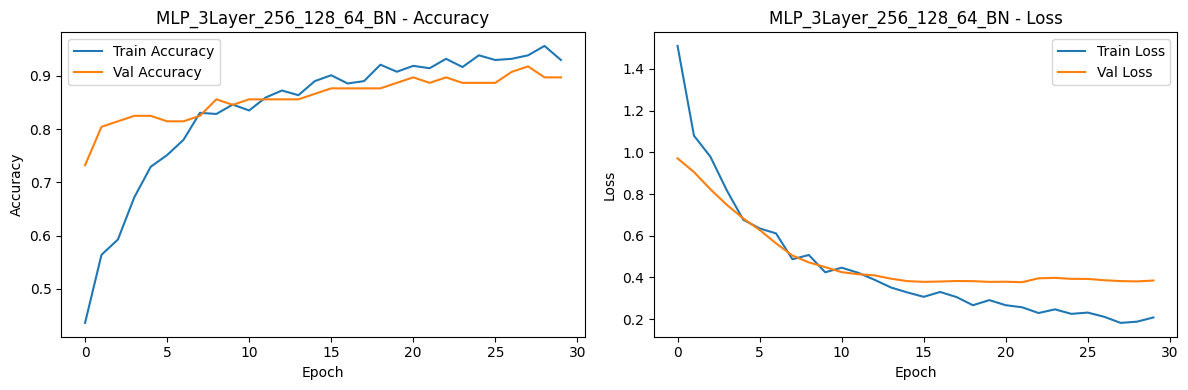

Best deep model by Macro F1: MLP_3Layer_256_128_64_BN


In [15]:
# =========================================================
# STEP 6: PLOT TRAINING CURVES FOR BEST DEEP MODEL
# =========================================================

best_dl_result = max(
    ablation_results + [focal_result, oversample_result],
    key=lambda x: x["Macro F1"]
)

history = best_dl_result["History"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title(f'{best_dl_result["Model"]} - Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title(f'{best_dl_result["Model"]} - Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("Best deep model by Macro F1:", best_dl_result["Model"])

=== Classification Report: MLP_3Layer_256_128_64_BN ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.850     0.850     0.850        20
Moderate_Quantum_Pathway      0.891     0.905     0.898        63
 Support_Quantum_Pathway      0.786     0.733     0.759        15

                accuracy                          0.867        98
               macro avg      0.842     0.829     0.835        98
            weighted avg      0.866     0.867     0.867        98



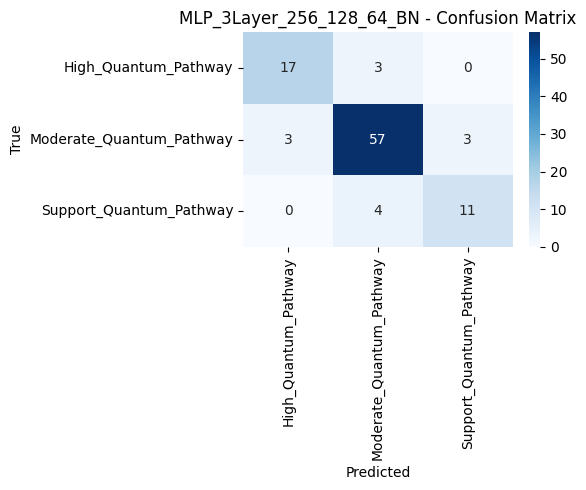

Support-tier prediction breakdown:


,true_label,pred_label
305,2,1
219,2,2
605,2,2
256,2,2
282,2,2
257,2,2
646,2,1
622,2,1
488,2,1
168,2,2


Counts of predicted labels for true Support students:
pred_label
1     4
2    11
Name: count, dtype: int64


In [16]:
# =========================================================
# STEP 7: ERROR ANALYSIS FOR SUPPORT CLASS
# =========================================================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

best_model_name = best_dl_result["Model"]

if best_model_name in trained_ablation_models:
    best_model = trained_ablation_models[best_model_name]
elif best_model_name == "MLP_FocalLoss_3Layer":
    best_model = focal_trained_model
elif best_model_name == "MLP_Oversampled_3Layer":
    best_model = oversample_trained_model
else:
    best_model = baseline_model

y_prob_best = best_model.predict(X_test_tf, verbose=0)
y_pred_best = np.argmax(y_prob_best, axis=1)
y_true = y_test_tf.numpy()

print(f"=== Classification Report: {best_model_name} ===")
print(classification_report(
    y_true,
    y_pred_best,
    target_names=label_encoder.classes_,
    digits=3,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

support_class_idx = list(label_encoder.classes_).index("Support_Quantum_Pathway")
support_mask = (y_true == support_class_idx)

support_cases = pd.DataFrame(X_test.numpy() if hasattr(X_test, "numpy") else X_test)
support_cases["true_label"] = y_true
support_cases["pred_label"] = y_pred_best
support_cases = support_cases[support_mask].copy()

print("Support-tier prediction breakdown:")
display(support_cases[["true_label", "pred_label"]].head(15))

print("Counts of predicted labels for true Support students:")
print(pd.Series(support_cases["pred_label"]).value_counts().sort_index())

In [17]:
# =========================================================
# STEP 8: AUTO-GENERATE SHORT RESULTS NARRATIVE
# =========================================================

best_row = comparison_df.iloc[0]
best_support_row = comparison_df.sort_values(by="Support F1", ascending=False).iloc[0]

print("Best overall model by Macro F1:")
print(best_row.to_string())
print("\nBest model for Support-tier F1:")
print(best_support_row.to_string())

print("\nSuggested interpretation:")
print(
    f"The strongest overall model was {best_row['Model']} "
    f"with test accuracy={best_row['Test Accuracy']:.3f} and macro-F1={best_row['Macro F1']:.3f}. "
    f"The best Support-tier detection came from {best_support_row['Model']} "
    f"with Support F1={best_support_row['Support F1']:.3f}. "
    f"These results show that architecture and loss design matter, especially under class imbalance."
)

Best overall model by Macro F1:
Model            MLP_3Layer_256_128_64_BN
Test Accuracy                    0.867347
Macro F1                         0.835419
High F1                              0.85
Moderate F1                      0.897638
Support F1                       0.758621

Best model for Support-tier F1:
Model            MLP_2Layer_128_64
Test Accuracy             0.846939
Macro F1                  0.812889
High F1                   0.769231
Moderate F1               0.883721
Support F1                0.785714

Suggested interpretation:
The strongest overall model was MLP_3Layer_256_128_64_BN with test accuracy=0.867 and macro-F1=0.835. The best Support-tier detection came from MLP_2Layer_128_64 with Support F1=0.786. These results show that architecture and loss design matter, especially under class imbalance.


In [19]:
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Infer input_dim and num_classes from tensors
input_dim = X_train_tf.shape[1]
num_classes = len(np.unique(y_train_tf))

print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

# ---------- Baseline MLP ----------
baseline_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_history = baseline_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    verbose=1,
)

# ---------- Class weights for imbalance ----------
# Use y_train_enc (NumPy array) instead of y_train_tf (Tensor) for compute_class_weight
classes = np.unique(y_train_enc)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc,
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print("Class weights:", class_weights)

# ---------- Improved MLP (class-weighted) ----------
improved_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

improved_history = improved_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1,
)

Input dimension: 41
Number of classes: 3
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5683 - loss: 0.9618 - val_accuracy: 0.6495 - val_loss: 0.8103
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6740 - loss: 0.7422 - val_accuracy: 0.7216 - val_loss: 0.6687
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7445 - loss: 0.6301 - val_accuracy: 0.7938 - val_loss: 0.5551
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7665 - loss: 0.5562 - val_accuracy: 0.8557 - val_loss: 0.4732
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8018 - loss: 0.4833 - val_accuracy: 0.8763 - val_loss: 0.4128
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8128 - loss: 0.4366 - val_accuracy: 0.8763 - val_loss: 0.3720
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8480 - loss: 0.3846 - val_accuracy: 0.8763 - val_loss: 0.3417
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8612 - loss:

In [20]:
# Compute class weights to handle imbalance and nod to equity goals
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_enc)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)
class_weights = {i: w for i, w in zip(classes, class_weights_array)}
class_weights

{np.int64(0): np.float64(1.644927536231884),
 np.int64(1): np.float64(0.5182648401826484),
 np.int64(2): np.float64(2.1619047619047618)}

In [21]:
improved_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_history = improved_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.4956 - loss: 0.9476 - val_accuracy: 0.4330 - val_loss: 0.9606
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6542 - loss: 0.6099 - val_accuracy: 0.6186 - val_loss: 0.8342
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7313 - loss: 0.4856 - val_accuracy: 0.7010 - val_loss: 0.7493
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7621 - loss: 0.4524 - val_accuracy: 0.7113 - val_loss: 0.7099
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7930 - loss: 0.3819 - val_accuracy: 0.7835 - val_loss: 0.6743
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8216 - loss: 0.3141 - val_accuracy: 0.7938 - val_loss: 0.6212
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8260 - loss: 0.3143 - val_accuracy: 0.8247 - val_loss: 0.5868
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8678 - loss: 0.2488 - val_accuracy: 0.8247 - v

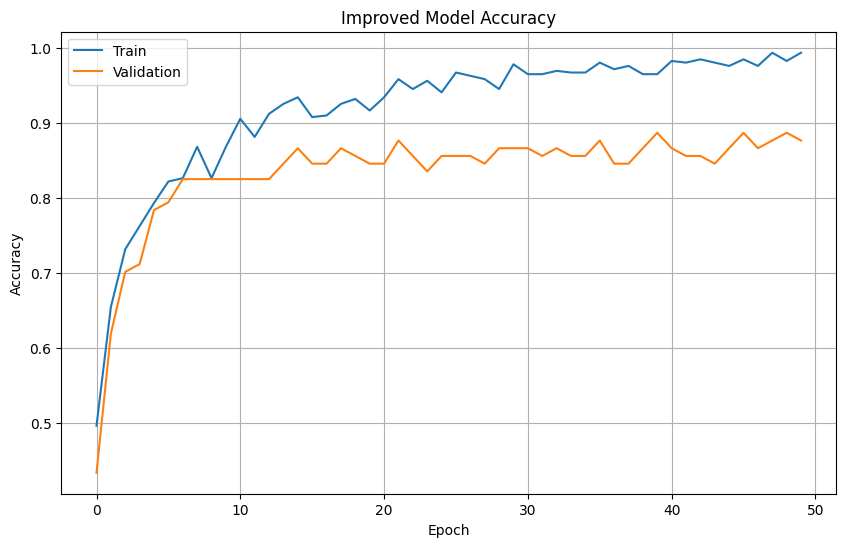

In [22]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(improved_history.history['accuracy'])
plt.plot(improved_history.history['val_accuracy'])
plt.title('Improved Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
=== Baseline MLP ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      1.000     0.750     0.857        20
Moderate_Quantum_Pathway      0.871     0.968     0.917        63
 Support_Quantum_Pathway      0.846     0.733     0.786        15

                accuracy                          0.888        98
               macro avg      0.906     0.817     0.853        98
            weighted avg      0.894     0.888     0.885        98



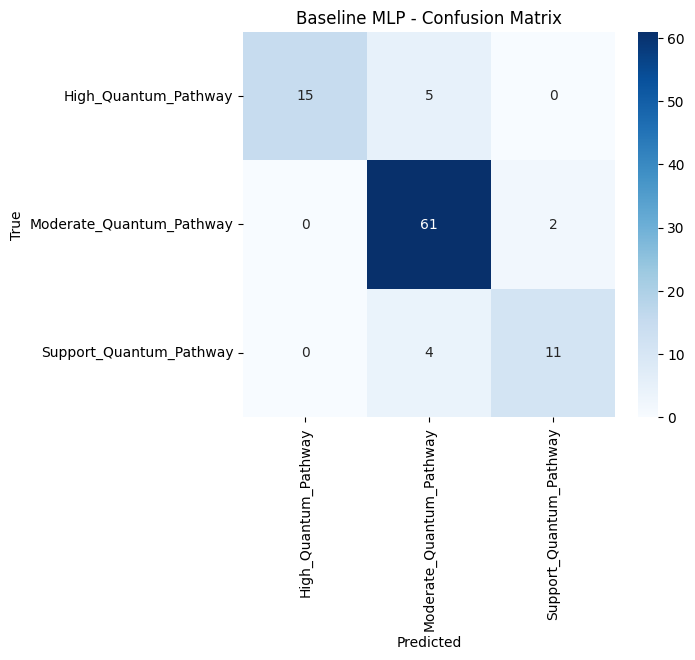

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
=== Improved MLP (Class-Weighted) ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.750     0.750     0.750        20
Moderate_Quantum_Pathway      0.815     0.841     0.828        63
 Support_Quantum_Pathway      0.615     0.533     0.571        15

                accuracy                          0.776        98
               macro avg      0.727     0.708     0.717        98
            weighted avg      0.771     0.776     0.773        98



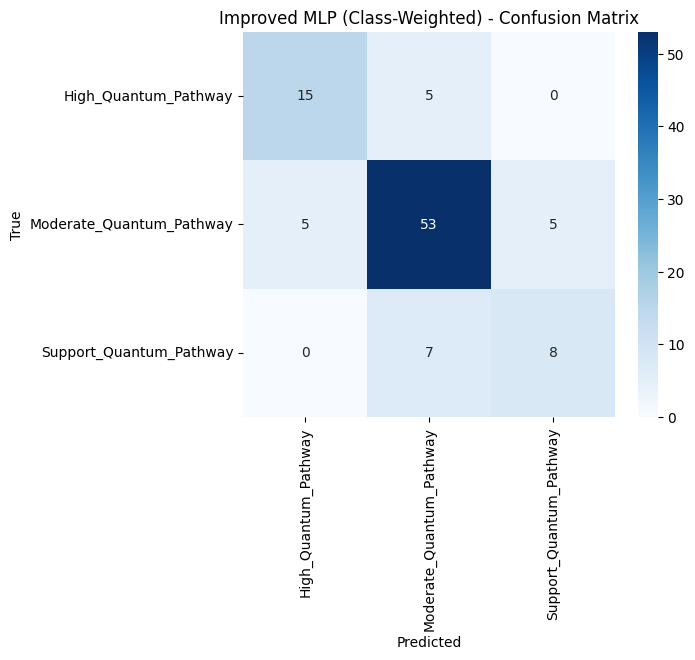

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X, y_true_enc, label_encoder, title="Model"):
    y_pred_probs = model.predict(X)
    y_pred_enc = y_pred_probs.argmax(axis=1)
    y_true = label_encoder.inverse_transform(y_true_enc)
    y_pred = label_encoder.inverse_transform(y_pred_enc)

    print(f"=== {title} ===")
    print(classification_report(y_true, y_pred, digits=3))

    cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cmap="Blues")
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Evaluate on test set
evaluate_model(baseline_model, X_test_tf, y_test_enc, label_encoder, title="Baseline MLP")
evaluate_model(improved_model, X_test_tf, y_test_enc, label_encoder, title="Improved MLP (Class-Weighted)")

## Standards Alignment: CS, Data Science, and Quantum Literacy

This project is intentionally framed at the intersection of K–12 computer science, data science, and emerging quantum literacy standards.

**CSTA K–12 Computer Science Standards.**  
The modeling task and feature interpretation are aligned with CSTA’s “Data and Analysis” concept and associated performance expectations, particularly in the 3B band where students are expected to use data analysis tools to identify patterns in complex systems and evaluate models and simulations.[web:55][web:57] By training a neural network on authentic student performance data, the project embodies these expectations in a concrete example of using data and models to reason about educational outcomes.

**K–12 Data Science and Data Literacy Progressions.**  
The project design is informed by national efforts to articulate K–12 data literacy and data science progressions, which emphasize engaging students in collecting, visualizing, and interpreting data, as well as reasoning ethically about data use.[web:60][web:66] The use of student-level tabular data, derived pathway labels, and interpretable evaluation metrics mirrors key practices highlighted in these progressions: defining meaningful variables, constructing models, and reflecting on limitations.

**Q–12 Quantum Education and Quantum Literacy.**  
The pathway labels are interpreted as “quantum literacy readiness tiers” that connect existing CS and data science competencies to early quantum information science experiences. This aligns with the Q–12 Education Partnership and AAPT’s call for integrating modern quantum topics into high school physics, mathematics, and computer science through developmentally appropriate pathways and resources.[web:61][web:67] In the narrative, each readiness tier can be associated with example experiences (e.g., data-focused qubit simulations, introductory superposition/entanglement activities) that build toward QISE-related competencies.

### Conceptual Standards Mapping

| Layer in Project                      | Example Standards Connections                                                                 |
|--------------------------------------|------------------------------------------------------------------------------------------------|
| Tabular student features (grades, study time, absences, etc.) | CSTA Data & Analysis concepts and practices; students using data to reason about performance.[web:55][web:58] |
| Derived `pathway_label` (High/Moderate/Support Quantum Pathway) | K–12 data science progressions’ focus on modeling, classification, and interpreting data-driven groupings.[web:60][web:66] |
| Deep learning model training and evaluation | CSTA expectations around evaluating models and simulations, and using computational tools to analyze data.[web:55][web:57] |
| Interpretation as quantum literacy readiness tiers | Q–12 / AAPT guidance on scaffolding quantum information science concepts into high school STEM pathways.[web:61][web:67] |
| Example recommended experiences per tier (e.g., intro data science + qubit simulations) | Data science frameworks and Q–12 resources that outline age-appropriate QISE learning experiences and tools.[web:60][web:67] |